# 03 — `trafico_intensidad`: intensidad de tráfico (capa 188)

**Origen.** ArcGIS REST del geoportal del Ajuntament, capa `OPENDATA/Trafico/188`.
Sondeo cada 15 minutos.

**Papel en el TFM.** Candidata a complementar la capa 192. Mientras la 192 da un
estado categórico, esta da una **medida continua** (`lectura`), que sería mejor
regresor si se pudiera unir con las otras dos fuentes. Este notebook es de
profundidad media y su objetivo principal es responder una pregunta concreta:

> ¿se puede unir la capa 188 con la 192, o son dos universos de tramos distintos?

De la respuesta depende que esta fuente entre en el modelo o se quede fuera.

In [1]:
import sys
from pathlib import Path

# El notebook debe correr tanto abierto desde notebooks/EDA como ejecutado
# desde la raíz del repo (nbclient, CI).
AQUI = Path("notebooks/EDA").resolve() if Path("notebooks/EDA").exists() else Path.cwd()
sys.path.insert(0, str(AQUI))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import eda_utils as eu

eu.estilo()
FUENTE = "trafico_intensidad"
print("corpus:", eu.dir_fuente(FUENTE))

corpus: C:\Users\oppen\Code\TFM\data\curated\source=trafico_intensidad


## 1. Censo y esquema

In [2]:
eu.censo(FUENTE)

,valor
métrica,
fuente,trafico_intensidad
filas,"713,048"
ficheros parquet,682
particiones (días),17
tamaño en disco,11.4 MB
ts_utc mínimo,2026-08-15 20:14:39.249822+00:00
ts_utc máximo,2026-08-31 16:18:02.901883+00:00


In [3]:
eu.esquema(FUENTE)

,columna,tipo
0,idtramo,VARCHAR
1,des_tramo,VARCHAR
2,lectura,DOUBLE
3,tipo_vehiculo,VARCHAR
4,fiwareid,VARCHAR
5,lat,DOUBLE
6,lon,DOUBLE
7,ts_utc,TIMESTAMP WITH TIME ZONE
8,ts_ingest_utc,TIMESTAMP WITH TIME ZONE
9,date,DATE


## 2. Calidad

In [4]:
eu.perfil_nulos(FUENTE)

,columna,nulos,pct_nulos,distintos,constante
6,lon,470008,65.915,286,False
5,lat,470008,65.915,286,False
2,lectura,65484,9.184,243,False
4,fiwareid,10914,1.531,386,False
3,tipo_vehiculo,5457,0.765,1,True
1,des_tramo,0,0.000,298,False
0,idtramo,0,0.000,389,False
7,ts_utc,0,0.000,1819,False
8,ts_ingest_utc,0,0.000,1819,False
9,date,0,0.000,17,False


In [5]:
eu.duplicados(FUENTE, ["ts_ingest_utc", "idtramo"])

,filas,combinaciones_unicas,duplicadas
0,713048,707591,5457


## 3. `lectura`: la variable continua

In [6]:
eu.resumen_numerico(FUENTE, ["lectura"]).round(2)

,n,media,mediana,moda,desv,min,p01,p25,p75,p99,max,iqr,atipicos_iqr,pct_atipicos
columna,,,,,,,,,,,,,,
lectura,647564,"1,079.240",539.000,0.000,"1,196.150",0.000,0.000,216.000,"1,656.000","5,064.000","6,012.000","1,440.000",25466,3.930


In [7]:
ceros = eu.sql(
    """
    SELECT count(*) AS filas,
           sum(CASE WHEN lectura IS NULL THEN 1 ELSE 0 END) AS nulos,
           sum(CASE WHEN lectura = 0 THEN 1 ELSE 0 END) AS ceros,
           sum(CASE WHEN lectura < 0 THEN 1 ELSE 0 END) AS negativos
    FROM {f}
    """,
    f=FUENTE,
)
ceros

,filas,nulos,ceros,negativos
0,713048,"65,484.000","18,190.000",0.000


**Cero y nulo no son lo mismo y aquí conviven.** Un cero es "pasaron cero
vehículos"; un nulo es "el sensor no dijo nada". Imputar los nulos a cero mete
tráfico inexistente en la serie, y descartar los ceros junto con los nulos borra
las horas de madrugada, que son reales. Hay que tratarlos por separado en
`features.py`.

Que no haya **ningún** valor negativo no significa que la fuente no los mande:
el colector convierte el centinela `-1` en nulo durante la ingesta
(`parse_trafico_intensidad`). Parte de los nulos de arriba son eso, y la
distinción entre "sensor sin dato" y "sensor ausente" ya no se puede recuperar
desde `curated/`.

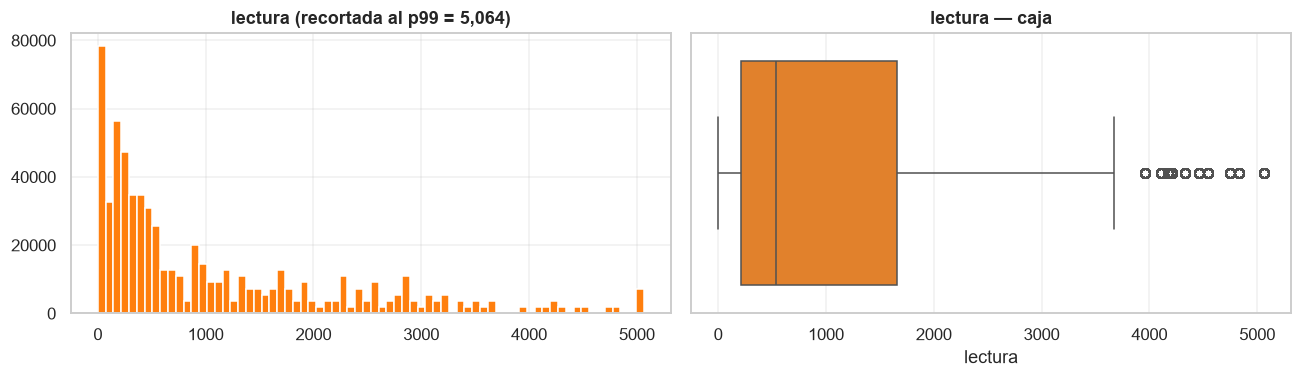

In [8]:
lec = eu.sql("SELECT lectura FROM {f} WHERE lectura IS NOT NULL", f=FUENTE)["lectura"]
p99 = lec.quantile(0.99)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.6))
a1.hist(lec.clip(upper=p99), bins=70, color=eu.PALETA[FUENTE])
a1.set_title(f"lectura (recortada al p99 = {p99:,.0f})")
sns.boxplot(x=lec.clip(upper=p99), ax=a2, color=eu.PALETA[FUENTE])
a2.set_title("lectura — caja")
plt.tight_layout()
plt.show()

## 4. `tipo_vehiculo`: una columna que no informa

In [9]:
eu.frecuencias(FUENTE, "tipo_vehiculo")

,valor,filas,pct,pct_acum
0,TRAFICO,707591,99.235,99.235
1,None,5457,0.765,100.000


Un único valor real más nulos. Como *feature* vale exactamente cero, y el único
uso legítimo es de control: si algún día apareciera un segundo valor, cambiaría el
significado de `lectura` y habría que enterarse.

## 5. ¿Se pueden unir la 188 y la 192?

Esta es la pregunta que justifica el notebook. Primero por identificador, que sería
la unión barata; después por proximidad geográfica, que sería la cara.

In [10]:
i188 = eu.sql("SELECT DISTINCT idtramo FROM {f} WHERE idtramo IS NOT NULL", f=FUENTE)
i192 = eu.sql("SELECT DISTINCT idtramo FROM {f} WHERE idtramo IS NOT NULL", f="trafico_estado")
print("188 — tipo:", i188["idtramo"].dtype, "| n =", len(i188), "| ejemplos:", i188["idtramo"].head(5).tolist())
print("192 — tipo:", i192["idtramo"].dtype, "| n =", len(i192), "| ejemplos:", i192["idtramo"].head(5).tolist())
comunes = set(i188["idtramo"].astype(str)) & set(i192["idtramo"].astype(str))
print("\nidtramo comunes tras castear a texto:", len(comunes))

188 — tipo: object | n = 389 | ejemplos: ['B47', 'A414', 'A25', 'A137', 'A98']
192 — tipo: float64 | n = 410 | ejemplos: [400.0, 369.0, 9.0, 324.0, 215.0]

idtramo comunes tras castear a texto: 0


**No hay unión por clave.** Los identificadores no solo tienen tipos distintos
(`VARCHAR` contra `DOUBLE`): son espacios de nombres diferentes —`A122`, `B47`
frente a `336`, `335`—. Casar `"336"` con `"A122"` no tiene sentido, y un
`merge` que devolviera filas aquí estaría casando basura.

Queda la vía geográfica: unir cada tramo de la 188 con el tramo de la 192 más
cercano, usando las geometrías de `data/reference/`.

In [11]:
g188, g192 = eu.geometria(FUENTE), eu.geometria("trafico_estado")
print(f"geometrías: {len(g188)} tramos en la 188, {len(g192)} en la 192")

R = 6_371_000.0
a = np.radians(g188[["lat", "lon"]].to_numpy())
b = np.radians(g192[["lat", "lon"]].to_numpy())
dlat = a[:, None, 0] - b[None, :, 0]
dlon = a[:, None, 1] - b[None, :, 1]
h = np.sin(dlat / 2) ** 2 + np.cos(a[:, None, 0]) * np.cos(b[None, :, 0]) * np.sin(dlon / 2) ** 2
dist = 2 * R * np.arcsin(np.sqrt(h))

vecino = pd.DataFrame(
    {
        "idtramo_188": g188["idtramo"].to_numpy(),
        "des_tramo": g188["des_tramo"].to_numpy(),
        "idtramo_192": g192["idtramo"].to_numpy()[dist.argmin(axis=1)],
        "denominacion": g192["denominacion"].to_numpy()[dist.argmin(axis=1)],
        "distancia_m": dist.min(axis=1),
    }
)
print(vecino["distancia_m"].describe().round(1).to_string())
vecino.sort_values("distancia_m").head(10).round(1)

geometrías: 389 tramos en la 188, 410 en la 192
count   389.000
mean    135.600
std     143.300
min       6.000
25%      23.700
50%      51.600
75%     232.100
max     871.900


,idtramo_188,des_tramo,idtramo_192,denominacion,distancia_m
320,A104,EUGENIA VIÑES,265.000,EUGENIA VIÑES (DE MEDITERRÁNEO A MARCOS SOPENA),6.000
157,A179,PAVIA,265.000,EUGENIA VIÑES (DE MEDITERRÁNEO A MARCOS SOPENA),6.000
3,A302,"Mª CRISTINA, AVDA.",336.000,MARIA CRISTINA,6.200
282,A76,COLON,38.000,COLÓN,6.300
210,A397,REUS (Entre Burjasot y Ruaya),513.000,C./ RUAYA (De Av. Constitución a C./ Sagunto).,7.300
17,A395,C/ RUAYA,513.000,C./ RUAYA (De Av. Constitución a C./ Sagunto).,7.300
222,A10,"ALAMEDA, PASEO DE",64.000,SANT PIUS V - TRINITAT - GUADALAVIAR - PLA DE ...,7.500
193,A112,GENERAL ELIO,64.000,SANT PIUS V - TRINITAT - GUADALAVIAR - PLA DE ...,7.500
270,A223,SAN PIO V,64.000,SANT PIUS V - TRINITAT - GUADALAVIAR - PLA DE ...,7.500
204,A173,PASEO CIUDADELA,293.000,PUENTE DE LA EXPOSICIÓN HACIA ALAMEDA,8.100


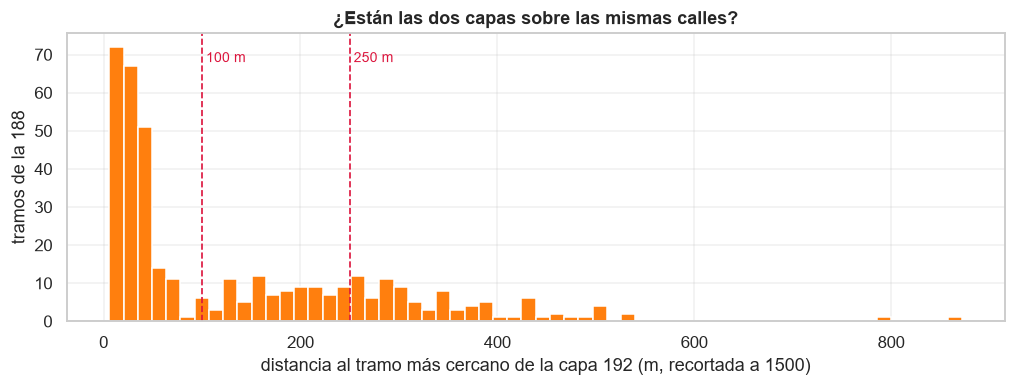

a menos de   50 m: 193 de 389 tramos (49.6 %)
a menos de  100 m: 221 de 389 tramos (56.8 %)
a menos de  250 m: 302 de 389 tramos (77.6 %)
a menos de  500 m: 384 de 389 tramos (98.7 %)


In [12]:
fig, ax = plt.subplots(figsize=(11, 3.4))
ax.hist(vecino["distancia_m"].clip(upper=1500), bins=60, color=eu.PALETA[FUENTE])
for u in (100, 250):
    ax.axvline(u, ls="--", lw=1.1, color="crimson")
    ax.text(u, ax.get_ylim()[1] * 0.9, f" {u} m", color="crimson", fontsize=9)
ax.set_xlabel("distancia al tramo más cercano de la capa 192 (m, recortada a 1500)")
ax.set_ylabel("tramos de la 188")
ax.set_title("¿Están las dos capas sobre las mismas calles?")
plt.show()

for u in (50, 100, 250, 500):
    n = int((vecino["distancia_m"] <= u).sum())
    print(f"a menos de {u:4d} m: {n:3d} de {len(vecino)} tramos ({100 * n / len(vecino):.1f} %)")

**La unión geográfica sí funciona.** La mitad de los tramos de la 188 tienen un
tramo de la 192 a menos de 50 metros y casi todos a menos de 500. Las dos capas
están instrumentando la misma red viaria con dos numeraciones distintas, no dos
ciudades distintas.

Dos avisos antes de darlo por hecho:

- la distancia se calcula entre los **puntos iniciales** de cada tramo, que es lo
  que guarda `reference/` en `lat`/`lon`. Dos tramos que recorren la misma calle
  en sentidos opuestos pueden salir a cientos de metros por empezar en extremos
  distintos: la medida acota por arriba, no resuelve;
- **la correspondencia no es uno a uno.** En la tabla de vecinos más cercanos, el
  mismo `idtramo_192` aparece como vecino de varios tramos de la 188 (`EUGENIA
  VIÑES` recoge dos, `SANT PIUS V` recoge tres). Un `merge` por vecino más cercano
  duplicaría filas; hay que decidir la agregación —¿la intensidad máxima de los
  tramos vecinos? ¿la media?— y escribirla.

Una unión seria exigiría comparar las `LINESTRING` completas con criterio de
sentido de circulación. Es trabajo de `prepare.py`, no de exploración, pero ahora
se sabe que el trabajo tiene sentido.

## 6. Perfil temporal de la intensidad

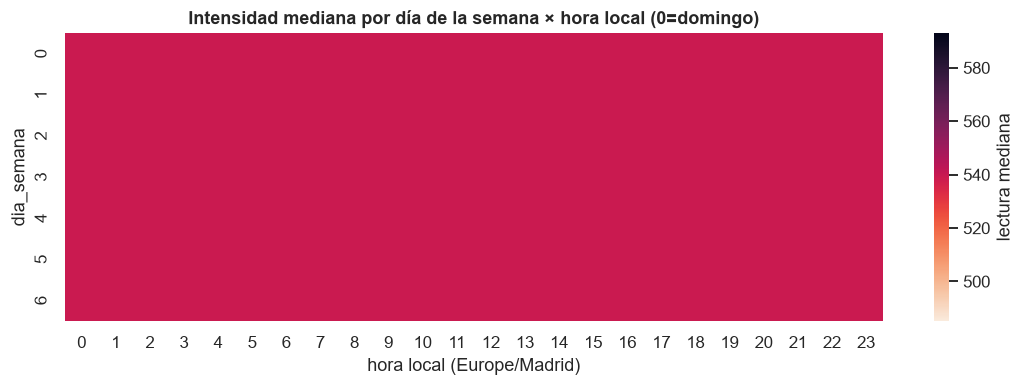

In [13]:
ph = eu.sql(
    """
    SELECT hour(ts_ingest_utc AT TIME ZONE 'Europe/Madrid') AS hora_local,
           dayofweek(ts_ingest_utc AT TIME ZONE 'Europe/Madrid') AS dia_semana,
           median(lectura) AS mediana,
           avg(lectura) AS media
    FROM {f} WHERE lectura IS NOT NULL GROUP BY 1, 2
    """,
    f=FUENTE,
)
pv = ph.pivot(index="dia_semana", columns="hora_local", values="mediana")

fig, ax = plt.subplots(figsize=(12, 3.4))
sns.heatmap(pv, cmap="rocket_r", ax=ax, cbar_kws={"label": "lectura mediana"})
ax.set_title("Intensidad mediana por día de la semana × hora local (0=domingo)")
ax.set_xlabel("hora local (Europe/Madrid)")
plt.show()

## 7. Hallazgos

1. **No hay unión por clave con la capa 192.** `idtramo` es `VARCHAR` con prefijo
   de letra aquí (`A122`, `B47`) y `DOUBLE` allí (`336`): espacios de nombres
   distintos, **intersección exactamente cero**. Cualquier `merge` por `idtramo`
   entre las dos capas es un error, y de los que no lanzan excepción — devuelve
   cero filas y parece un problema de datos.
2. **La unión geográfica sí es viable**, y esto cambia el veredicto sobre la
   fuente: la mitad de los tramos de la 188 tienen vecino de la 192 a menos de
   50 m, casi todos a menos de 500. Instrumentan la misma red con dos
   numeraciones. Pero la correspondencia **no es uno a uno** y un `merge` por
   vecino más cercano duplica filas: hay que definir la agregación.
3. **Esta capa aporta lo que a la 192 le falta.** Vista la 192 —congestión real en
   menos del 0,03 % de las filas, cuatro de cada cinco tramos constantes—, una
   medida **continua** de intensidad deja de ser un complemento opcional y pasa a
   ser una candidata seria a variable explicativa principal.
4. **Cero y nulo son cosas distintas en `lectura`.** Imputar nulos a cero inventa
   tráfico; descartar los ceros borra la madrugada real. Y el centinela `-1` ya se
   convirtió en nulo en ingesta, así que esa distinción se perdió antes de
   `curated/`.
5. **`tipo_vehiculo` es constante.** Fuera de las features; solo sirve como
   chivato de que la fuente cambie.
6. **Cadencia de 15 minutos**, tres veces más lenta que la 192. Si esta capa entra
   en la fusión, es ella la que fija la resolución temporal del modelo.